In [ ]:
import pandas as pd
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns
)

df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
#dataset dimensions

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1372, 5)
Number of Rows: 1372
Number of Columns: 5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
print('Class distribution (counts):')
print(df['Class'].value_counts())
print('\nClass distribution (proportions):')
print(df['Class'].value_counts(normalize=True))

Class distribution (counts):
Class
0    762
1    610
Name: count, dtype: int64

Class distribution (proportions):
Class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


TASK 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Global styling: bold axis labels, tick labels, and legend text; 600 dpi exports
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'savefig.dpi': 600,
    'savefig.format': 'eps',
    'savefig.bbox': 'tight'
})


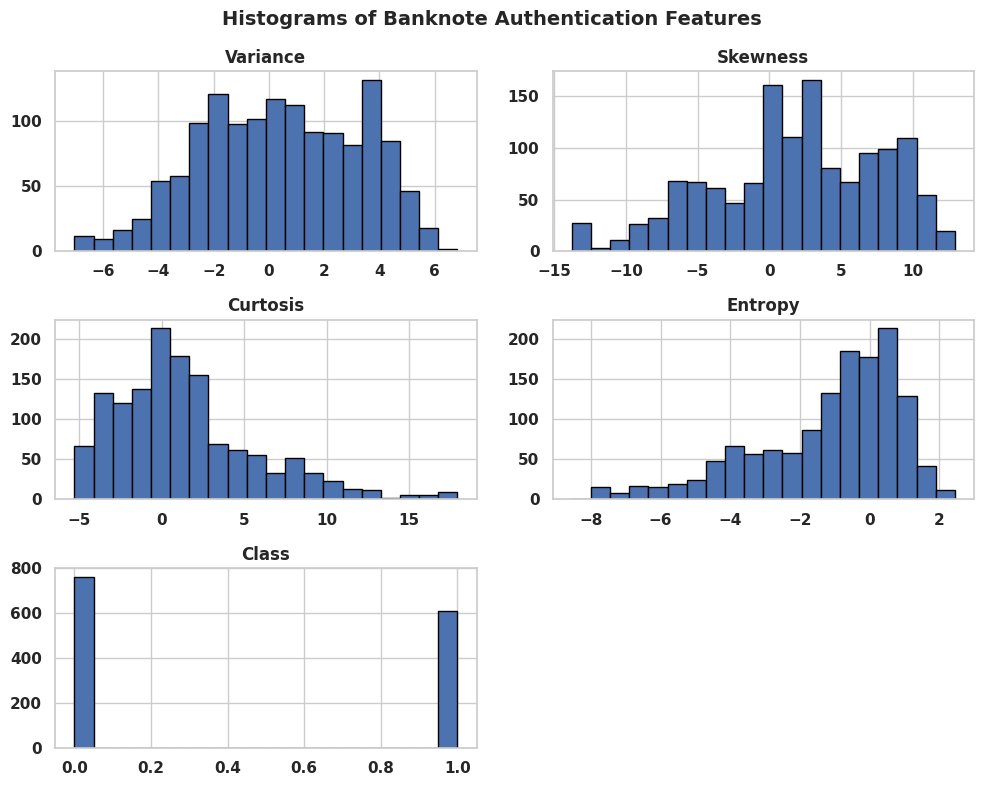

In [ ]:

df.hist(figsize=(10, 8), bins=20, edgecolor='black')

plt.suptitle("Histograms of Banknote Authentication Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("histograms.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


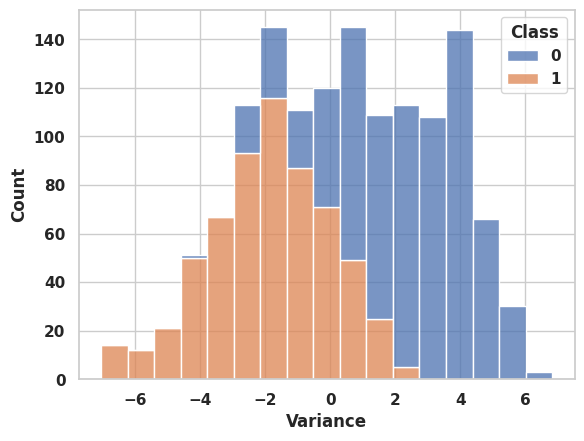

In [ ]:
sns.histplot(data=df,
             x='Variance',
             hue='Class',
             multiple='stack')
plt.savefig("variance_histplot_by_class.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


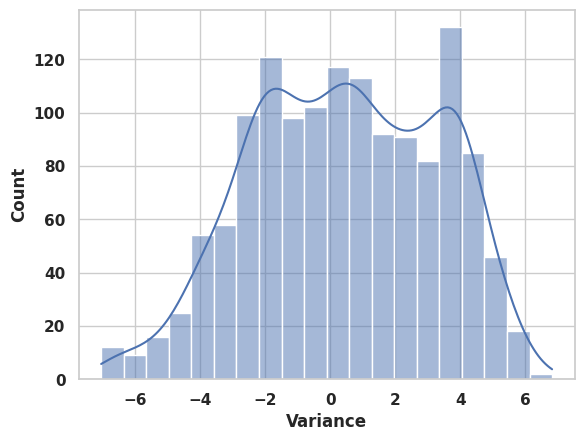

In [ ]:
sns.histplot(df['Variance'], bins=20, kde=True)
plt.savefig("variance_histplot_kde.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


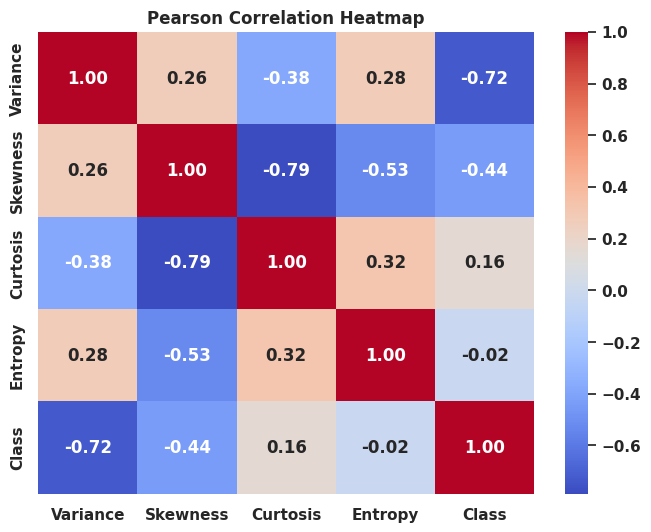

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(method='pearson'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Pearson Correlation Heatmap")
plt.savefig("correlation_heatmap.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


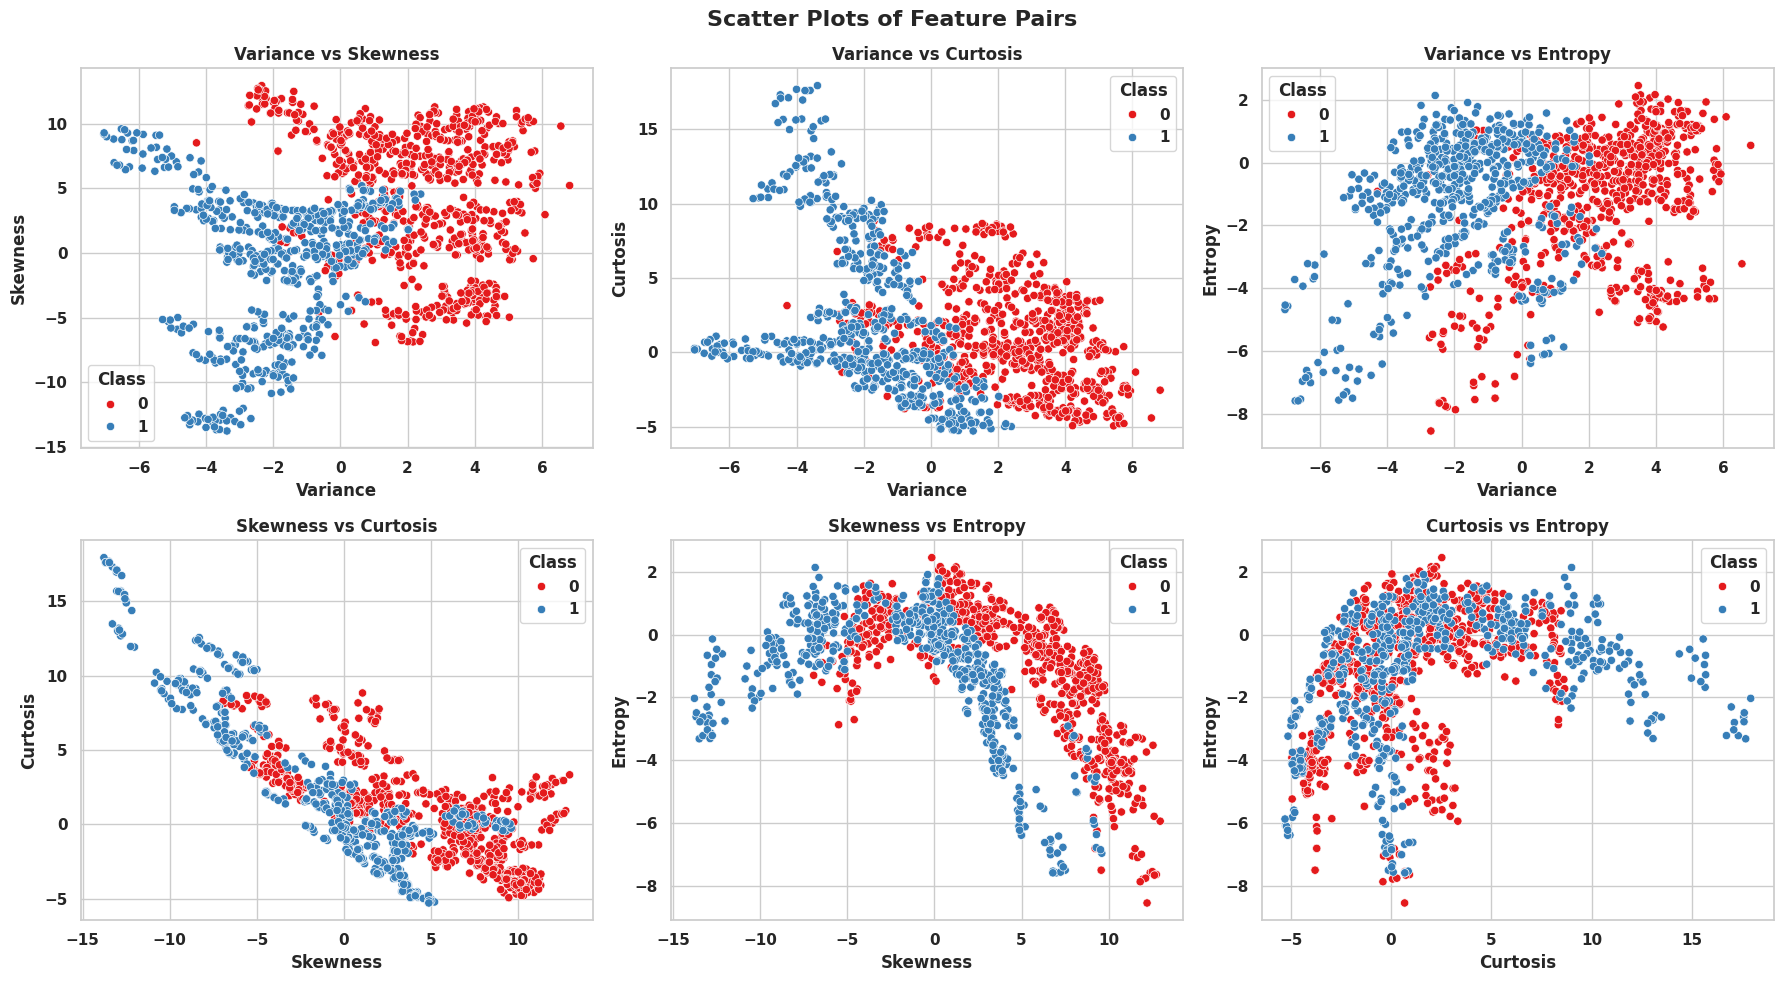

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Numerical feature names (updated to new names)
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

# Generate all unique pairs
pairs = list(combinations(features, 2))

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each scatter plot
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue='Class',  # Updated hue to 'Class'
        palette='Set1',
        ax=ax
    )
    ax.set_title(f'{x} vs {y}')
    ax.set_xlabel(x, fontweight='bold')
    ax.set_ylabel(y, fontweight='bold')
    leg = ax.legend(title='Class')
    plt.setp(leg.get_texts(), fontweight='bold')
    plt.setp(leg.get_title(), fontweight='bold')

plt.suptitle('Scatter Plots of Feature Pairs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("scatter_feature_pairs.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


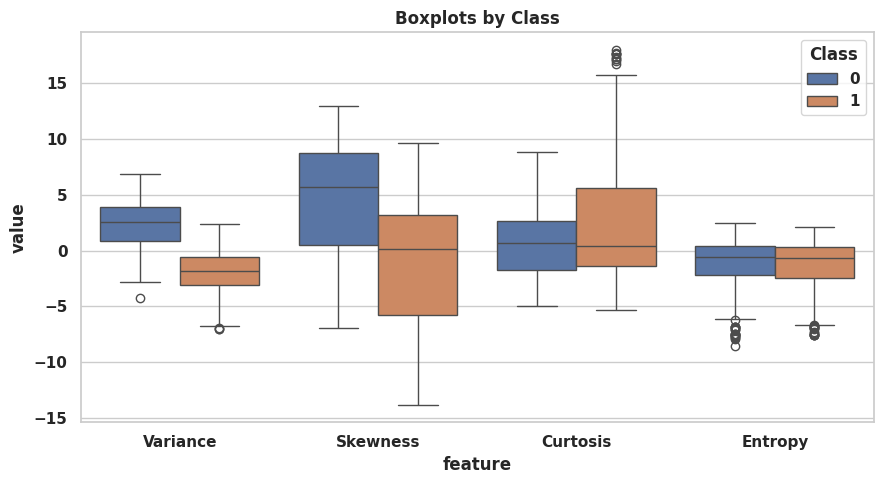

In [ ]:
plt.figure(figsize=(9, 5))
melted = df.melt(id_vars='Class', var_name="feature", value_name="value")
sns.boxplot(data=melted, x="feature", y="value", hue='Class')
plt.title("Boxplots by Class")
leg = plt.legend(title='Class')
plt.setp(leg.get_texts(), fontweight='bold')
plt.setp(leg.get_title(), fontweight='bold')
plt.tight_layout()
plt.savefig("boxplots_by_class.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns="Class").values
y = df["Class"].values

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (1097, 4)
Testing data shape: (275, 4)
Training labels shape: (1097,)
Testing labels shape: (275,)


In [ ]:
import numpy as np

print("\n===== TASK 4 & TASK 5: PERCEPTRON IMPLEMENTATION AND TRAINING =====")

# -------------------------------------------------
# Parameters
# -------------------------------------------------

learning_rate = 0.01
epochs = 50

# -------------------------------------------------
# Weight Initialization
# -------------------------------------------------

weights = np.zeros(X_train.shape[1])

# -------------------------------------------------
# Bias Initialization
# -------------------------------------------------

bias = 0

print("Initial Weights:", weights)
print("Initial Bias:", bias)

# Store training history (optional)
misclassified_history = []
weight_history = []
bias_history = []

# -------------------------------------------------
# Model Training
# -------------------------------------------------

for epoch in range(epochs):

    misclassified = 0

    # Train using every sample
    for i in range(len(X_train)):

        # -----------------------------
        # Forward Propagation
        # -----------------------------

        z = np.dot(X_train[i], weights) + bias

        # -----------------------------
        # Step Activation Function
        # -----------------------------

        if z >= 0:
            prediction = 1
        else:
            prediction = 0

        # -----------------------------
        # Perceptron Learning Rule
        # -----------------------------

        error = y_train[i] - prediction

        weights = weights + learning_rate * error * X_train[i]
        bias = bias + learning_rate * error

        if error != 0:
            misclassified += 1

    # Save history
    misclassified_history.append(misclassified)
    weight_history.append(weights.copy())
    bias_history.append(bias)

    # Display training progress
    print(f"\nEpoch {epoch + 1}")
    print("Misclassified Samples:", misclassified)
    print("Updated Weights:", weights)
    print("Updated Bias:", bias)

    # Stop if no errors remain
    if misclassified == 0:
        print("\nTraining Converged Successfully!")
        break


===== TASK 4 & TASK 5: PERCEPTRON IMPLEMENTATION AND TRAINING =====
Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0

Epoch 1
Misclassified Samples: 53
Updated Weights: [-0.07172913 -0.06459747 -0.06394283  0.00440934]
Updated Bias: -0.03

Epoch 2
Misclassified Samples: 22
Updated Weights: [-0.07362142 -0.07571125 -0.07106102  0.00836357]
Updated Bias: -0.05

Epoch 3
Misclassified Samples: 37
Updated Weights: [-0.10137147 -0.11857167 -0.06506799 -0.00163016]
Updated Bias: -0.04

Epoch 4
Misclassified Samples: 18
Updated Weights: [-0.10705102 -0.12940634 -0.07142015  0.0009985 ]
Updated Bias: -0.04

Epoch 5
Misclassified Samples: 20
Updated Weights: [-0.10221135 -0.1239463  -0.10340289  0.00528526]
Updated Bias: -0.060000000000000005

Epoch 6
Misclassified Samples: 16
Updated Weights: [-0.11243158 -0.12818908 -0.11034737  0.00804979]
Updated Bias: -0.060000000000000005

Epoch 7
Misclassified Samples: 16
Updated Weights: [-0.11921661 -0.1247428  -0.12048208 -0.00988522]
Updated Bias: -0.0

In [ ]:
y_pred = []

for sample in X_test:

    z = np.dot(sample, weights) + bias

    if z >= 0:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)


===== TASK 6: MODEL EVALUATION =====
Accuracy : 0.9636
Precision: 0.9308
Recall   : 0.9918
F1-score : 0.9603

Confusion Matrix:
[[144   9]
 [  1 121]]


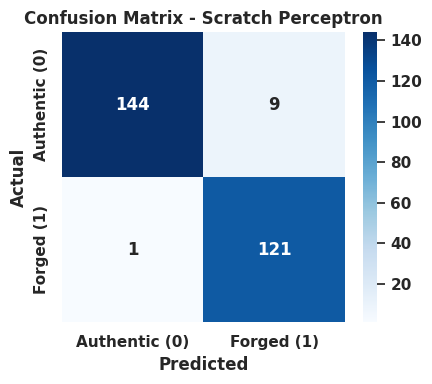

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n===== TASK 6: MODEL EVALUATION =====")

# -----------------------------------
# Prediction on Test Data
# -----------------------------------

y_pred = []

for sample in X_test:

    z = np.dot(sample, weights) + bias

    if z >= 0:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)


# -----------------------------------
# Evaluation Metrics
# -----------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_pred)


# -----------------------------------
# Display Results
# -----------------------------------

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)


# -----------------------------------
# Confusion Matrix Visualization
# -----------------------------------

plt.figure(figsize=(4.5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Authentic (0)", "Forged (1)"],
    yticklabels=["Authentic (0)", "Forged (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Scratch Perceptron")

plt.tight_layout()
plt.show()

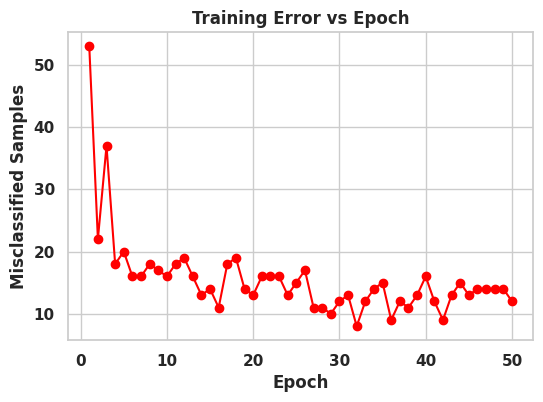

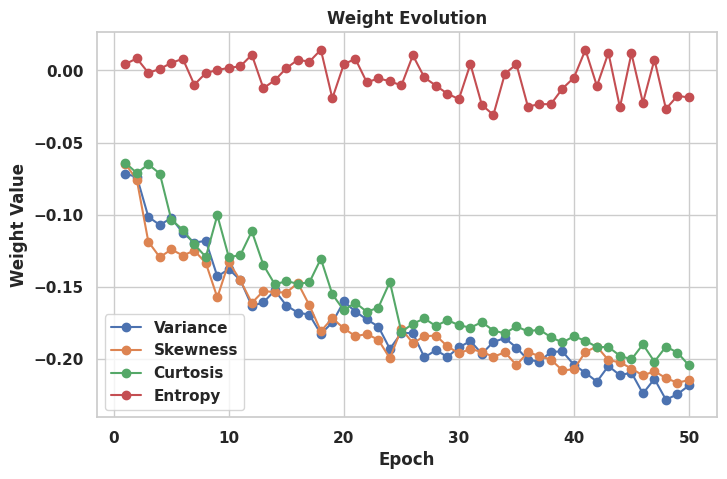

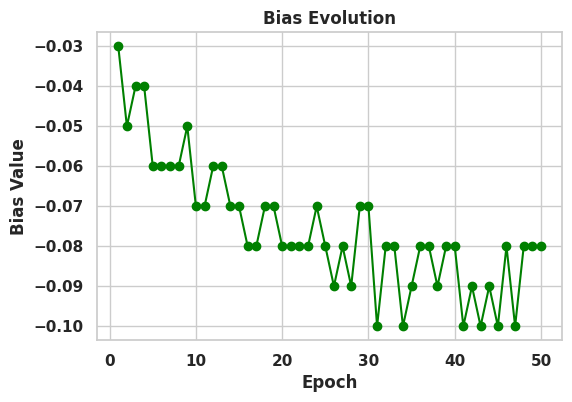

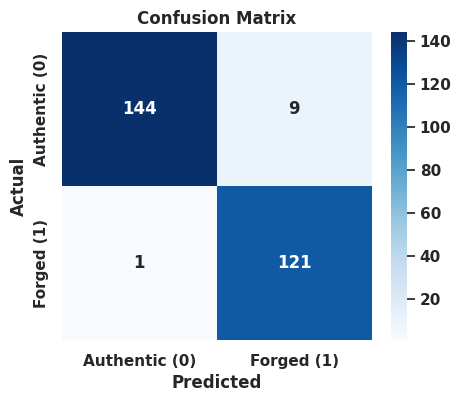

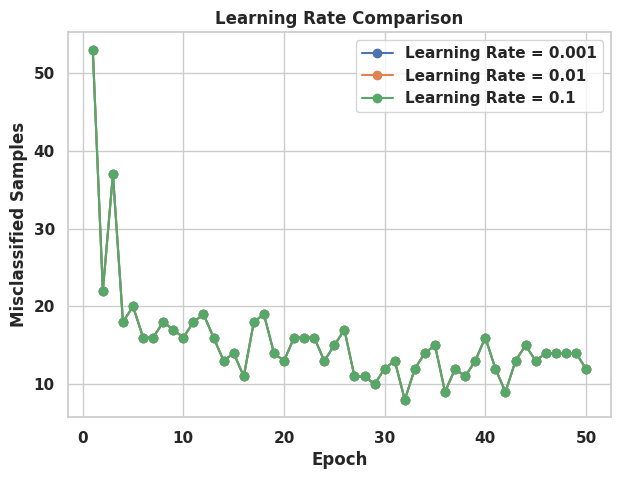

In [ ]:
# ============================================================
# ADDITIONAL ANALYSIS AND VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# ============================================================
# 1. Training Error vs Epoch
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(misclassified_history)+1),
    misclassified_history,
    marker='o',
    color='red'
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)

plt.savefig("training_error_vs_epoch.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 2. Weight Evolution
# ============================================================

weight_history_array = np.array(weight_history)

feature_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy"
]

plt.figure(figsize=(8,5))

for i in range(weight_history_array.shape[1]):

    plt.plot(
        range(1, len(weight_history_array)+1),
        weight_history_array[:,i],
        marker='o',
        label=feature_names[i]
    )


plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("weight_evolution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 3. Bias Evolution
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(bias_history)+1),
    bias_history,
    marker='o',
    color='green'
)

plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)

plt.savefig("bias_evolution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 4. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Authentic (0)",
        "Forged (1)"
    ],
    yticklabels=[
        "Authentic (0)",
        "Forged (1)"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 5. Learning Rate Comparison
# ============================================================

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(7,5))


for lr in learning_rates:

    temp_weights = np.zeros(X_train.shape[1])
    temp_bias = 0

    error_history = []


    for epoch in range(50):

        errors = 0


        for i in range(len(X_train)):

            z = np.dot(
                X_train[i],
                temp_weights
            ) + temp_bias


            prediction = 1 if z >= 0 else 0


            error = y_train[i] - prediction


            temp_weights += (
                lr * error * X_train[i]
            )

            temp_bias += lr * error


            if error != 0:
                errors += 1


        error_history.append(errors)



    plt.plot(
        range(1,51),
        error_history,
        marker='o',
        label=f"Learning Rate = {lr}"
    )


plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("learning_rate_comparison.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 6. Decision Boundary (Using Variance and Skewness)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Select two features
X_boundary = df[
    ["Variance","Skewness"]
].values

y_boundary = df["Class"].values


# Normalize
scaler = StandardScaler()

X_boundary = scaler.fit_transform(
    X_boundary
)


# Initialize parameters

boundary_weights = np.zeros(2)
boundary_bias = 0

lr = 0.01


# Train perceptron on two features

for epoch in range(50):

    for i in range(len(X_boundary)):

        z = np.dot(
            X_boundary[i],
            boundary_weights
        ) + boundary_bias


        prediction = 1 if z >= 0 else 0


        error = y_boundary[i] - prediction


        boundary_weights += (
            lr * error * X_boundary[i]
        )

        boundary_bias += lr * error





===== OPTIONAL: DECISION BOUNDARY VISUALIZATION =====


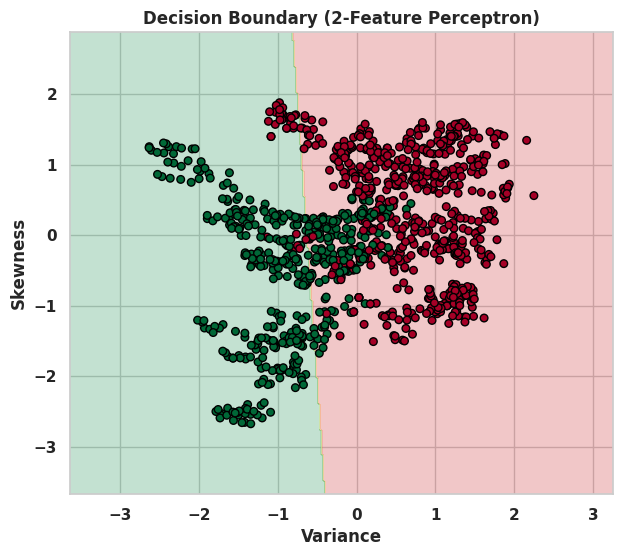

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n===== OPTIONAL: DECISION BOUNDARY VISUALIZATION =====")

# -------------------------------------------------
# Select two features
# 0 -> Variance
# 1 -> Skewness
# -------------------------------------------------

feature_idx = (0, 1)

X2 = X_train[:, feature_idx]


# -------------------------------------------------
# Initialize perceptron parameters
# -------------------------------------------------

eta = 0.01
n_epochs = 50

weights_2 = np.zeros(2)
bias_2 = 0


# -------------------------------------------------
# Train 2-feature perceptron
# -------------------------------------------------

for epoch in range(n_epochs):

    errors = 0

    for i in range(len(X2)):

        # Forward propagation
        z = np.dot(X2[i], weights_2) + bias_2

        # Step activation
        prediction = 1 if z >= 0 else 0

        # Error
        error = y_train[i] - prediction

        # Perceptron learning rule
        weights_2 += eta * error * X2[i]
        bias_2 += eta * error

        if error != 0:
            errors += 1


    if errors == 0:
        break



# -------------------------------------------------
# Create mesh grid for decision regions
# -------------------------------------------------

x_min = X2[:,0].min() - 1
x_max = X2[:,0].max() + 1

y_min = X2[:,1].min() - 1
y_max = X2[:,1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


# Predict grid points

grid = np.c_[xx.ravel(), yy.ravel()]

grid_predictions = []


for point in grid:

    z = np.dot(point, weights_2) + bias_2

    if z >= 0:
        grid_predictions.append(1)
    else:
        grid_predictions.append(0)


grid_predictions = np.array(grid_predictions)

grid_predictions = grid_predictions.reshape(xx.shape)



# -------------------------------------------------
# Plot decision boundary
# -------------------------------------------------

plt.figure(figsize=(7,6))


# Decision regions
plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25,
    cmap="RdYlGn"
)


# Training samples
plt.scatter(
    X2[:,0],
    X2[:,1],
    c=y_train,
    cmap="RdYlGn",
    edgecolor="black",
    s=30
)


plt.xlabel("Variance")
plt.ylabel("Skewness")

plt.title(
    "Decision Boundary (2-Feature Perceptron)"
)

plt.grid(True)

plt.savefig("decision_boundary.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd

# ================================
# TRAINING SUMMARY
# ================================

print("\n===== TRAINING SUMMARY =====")

summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        len(df),
        "80% / 20%",
        learning_rate,
        len(misclassified_history),
        str(np.round(weights, 4)),
        round(bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

print(summary.to_string(index=False))


===== TRAINING SUMMARY =====
       Parameter                             Value
    Dataset Size                              1372
Train/Test Split                         80% / 20%
   Learning Rate                              0.01
          Epochs                                50
   Final Weights [-0.2182 -0.2145 -0.2043 -0.0187]
      Final Bias                             -0.08
        Accuracy                            0.9636
       Precision                            0.9308
          Recall                            0.9918
        F1-score                            0.9603


In [ ]:
# ================================
# EPOCH-WISE LEARNING
# ================================

epoch_table = []

for i in range(len(misclassified_history)):

    epoch_table.append([
        i + 1,
        misclassified_history[i],
        weight_history[i][0],
        weight_history[i][1],
        bias_history[i]
    ])


epoch_df = pd.DataFrame(
    epoch_table,
    columns=[
        "Epoch",
        "Errors",
        "Weight 1",
        "Weight 2",
        "Bias"
    ]
)

print("\n===== EPOCH-WISE LEARNING =====")

print(
    epoch_df.round(4).to_string(index=False)
)


===== EPOCH-WISE LEARNING =====
 Epoch  Errors  Weight 1  Weight 2  Bias
     1      53   -0.0717   -0.0646 -0.03
     2      22   -0.0736   -0.0757 -0.05
     3      37   -0.1014   -0.1186 -0.04
     4      18   -0.1071   -0.1294 -0.04
     5      20   -0.1022   -0.1239 -0.06
     6      16   -0.1124   -0.1282 -0.06
     7      16   -0.1192   -0.1247 -0.06
     8      18   -0.1181   -0.1334 -0.06
     9      17   -0.1427   -0.1573 -0.05
    10      16   -0.1376   -0.1329 -0.07
    11      18   -0.1452   -0.1454 -0.07
    12      19   -0.1631   -0.1610 -0.06
    13      16   -0.1607   -0.1528 -0.06
    14      13   -0.1524   -0.1535 -0.07
    15      14   -0.1628   -0.1539 -0.07
    16      11   -0.1678   -0.1472 -0.08
    17      18   -0.1692   -0.1626 -0.08
    18      19   -0.1825   -0.1806 -0.07
    19      14   -0.1746   -0.1717 -0.07
    20      13   -0.1600   -0.1786 -0.08
    21      16   -0.1670   -0.1841 -0.08
    22      16   -0.1725   -0.1826 -0.08
    23      16   -0.1774

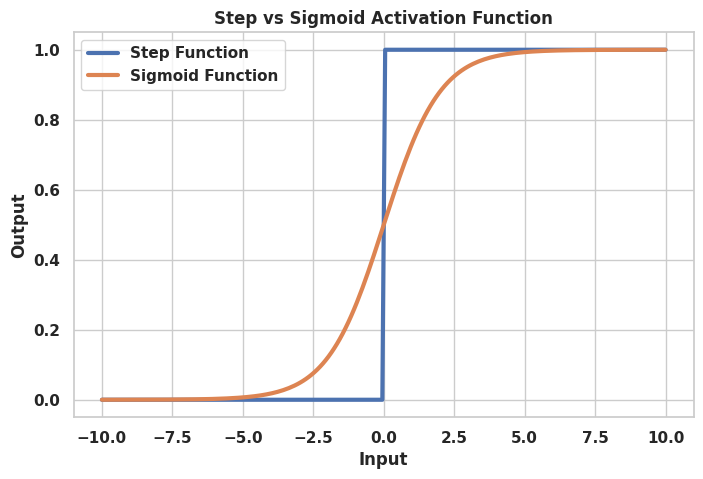

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Input range
x = np.linspace(-10, 10, 200)


# Step Activation Function
step_output = np.where(x >= 0, 1, 0)


# Sigmoid Activation Function
sigmoid_output = 1 / (1 + np.exp(-x))


# Plot
plt.figure(figsize=(8,5))

plt.plot(
    x,
    step_output,
    label="Step Function",
    linewidth=3
)

plt.plot(
    x,
    sigmoid_output,
    label="Sigmoid Function",
    linewidth=3
)

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Step vs Sigmoid Activation Function")

leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("step_vs_sigmoid_activation.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

In [ ]:
# Create sklearn perceptron

sk_model = Perceptron(
    eta0=0.01,
    max_iter=50,
    random_state=7
)


# Train

sk_model.fit(
    X_train,
    y_train
)


# Prediction

sk_pred = sk_model.predict(
    X_test
)


# Accuracy

sk_accuracy = accuracy_score(
    y_test,
    sk_pred
)


print("Scikit-learn Perceptron Accuracy:",
      sk_accuracy)


print("\nScikit-learn Weights:")
print(sk_model.coef_)


print("\nScikit-learn Bias:")
print(sk_model.intercept_)

Scikit-learn Perceptron Accuracy: 0.9454545454545454

Scikit-learn Weights:
[[-0.12890256 -0.13029207 -0.08368971 -0.00935735]]

Scikit-learn Bias:
[-0.03]


In [ ]:
print("\nScratch Perceptron Accuracy:",
      accuracy)


print("\nScratch Weights:")
print(weights)


print("\nScratch Bias:")
print(bias)


Scratch Perceptron Accuracy: 0.9636363636363636

Scratch Weights:
[-0.21822076 -0.21445339 -0.20429861 -0.01871864]

Scratch Bias:
-0.08


In [ ]:
import numpy as np


# XOR dataset

X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y_xor = np.array([
    0,
    1,
    1,
    0
])


# Initialize

weights_xor = np.zeros(2)

bias_xor = 0

lr = 0.1


# Training

for epoch in range(20):

    errors = 0


    for i in range(len(X_xor)):


        z = (
            np.dot(
                X_xor[i],
                weights_xor
            )
            +
            bias_xor
        )


        prediction = (
            1 if z >= 0
            else 0
        )


        error = (
            y_xor[i]
            -
            prediction
        )


        weights_xor += (
            lr *
            error *
            X_xor[i]
        )


        bias_xor += (
            lr *
            error
        )


        if error != 0:
            errors += 1


    print(
        "Epoch:",
        epoch+1,
        "Errors:",
        errors
    )


print("\nFinal Weights:")
print(weights_xor)

print("Final Bias:")
print(bias_xor)

Epoch: 1 Errors: 3
Epoch: 2 Errors: 3
Epoch: 3 Errors: 4
Epoch: 4 Errors: 4
Epoch: 5 Errors: 4
Epoch: 6 Errors: 4
Epoch: 7 Errors: 4
Epoch: 8 Errors: 4
Epoch: 9 Errors: 4
Epoch: 10 Errors: 4
Epoch: 11 Errors: 4
Epoch: 12 Errors: 4
Epoch: 13 Errors: 4
Epoch: 14 Errors: 4
Epoch: 15 Errors: 4
Epoch: 16 Errors: 4
Epoch: 17 Errors: 4
Epoch: 18 Errors: 4
Epoch: 19 Errors: 4
Epoch: 20 Errors: 4

Final Weights:
[-0.1  0. ]
Final Bias:
0.0
